## EFM: Toy experiments

In [21]:
!pip install ml_collections

In [22]:
import torch

import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import sys
#sys.path.append("/trinity/home/a.kolesov/EFM/")
from src.data import MultiDimStackedGauss, MultiDimStackedMixtureGauss, SwissRollSampler
from src.utils import Config
from src.efm_field import EFM
from src.ode import DippoleGroundTrurthEFMODESolver,  LearnDippoleEFMODESolver
from src.models  import DefineMLP, ToyNet

import warnings
warnings.filterwarnings('ignore')

## 1. Gaussian to Mixture

In [23]:
config = Config()

##### common #####
config.device = 'cuda'
config.DIM = 3
config.L = 6.

config.KV = {"z":[-5,5.], "x":[1e-5,8.], "y": [-8,8]}
config.mesh_num_points = 7
##### common #####

##### p_data #####
config.p = Config()
config.p.dim = config.DIM -1
config.p.mean = (0.,0.)
config.p.x_loc = 0.
config.p.std = 1.
config.p.cov = None
##### p_data #####

##### q_data #####
config.q =  Config()
config.q.dim = config.DIM -1
config.q.num_components = 2
config.q.mix_probs = (0.5,0.5)
config.q.means = ((-8.,0.),(8.,0.))
config.q.stds = (1.,1.)
config.q.cov = None
config.q.x_loc = config.L
##### q_data #####

##### EFM #####
config.training = Config()

config.training = Config()
config.training.stability = True
config.training.gamma = 1e-7
config.training.epsilon=0.3
config.training.interpolation='mesh'
config.training.M = 20.
config.training.tau = .08
config.training.sigma_end = .8
config.training.batch_size =2048
config.training.small_batch_size =1024
config.training.restrict_M = False
config.training.training_steps = 8000
##### EFM #####

config.ode = Config()
config.ode.step = 1.
config.ode.gamma = 0.
config.ode.behind_step = 1.5
config.ode.behind_num_steps = 350

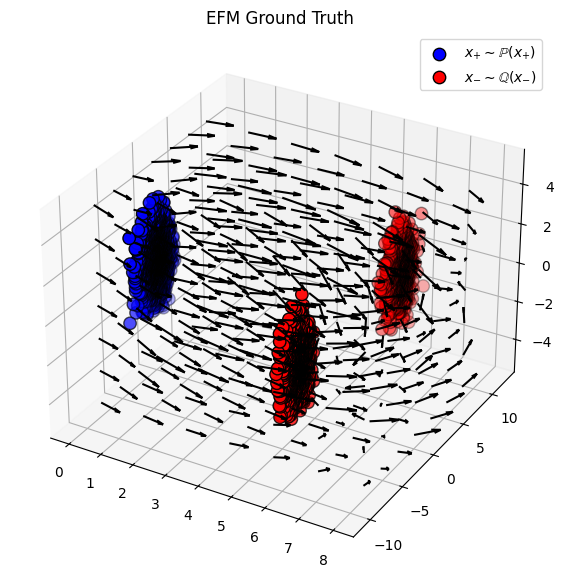

In [24]:
p_dist = MultiDimStackedGauss(config)
q_dist = MultiDimStackedMixtureGauss(config)

p_samples = p_dist.sample(config.training.batch_size).to(config.device)
q_samples = q_dist.sample(config.training.batch_size).to(config.device)
efm = EFM(config)

mesh = efm.get_mesh(kv=config.KV,
                    mesh_num_points=config.mesh_num_points).to(config.device)
field = efm.GroundTruth(perturbed_samples_vec=mesh.clone(),
                        p_samples=p_samples, q_samples=q_samples)

fig = efm.plotVectorField(mesh=mesh, field=field,
                          p_samples=p_samples,
                          q_samples=q_samples)

In [25]:
ode = DippoleGroundTrurthEFMODESolver(config)
init = p_dist.sample(config.training.small_batch_size).to(config.device)
init[:,0] = config.training.epsilon
maps, traj = ode(efm, init , p_samples.clone(), q_samples.clone())
traj = torch.stack(traj,dim=0)

100%|██████████| 350/350 [00:00<00:00, 554.98it/s]


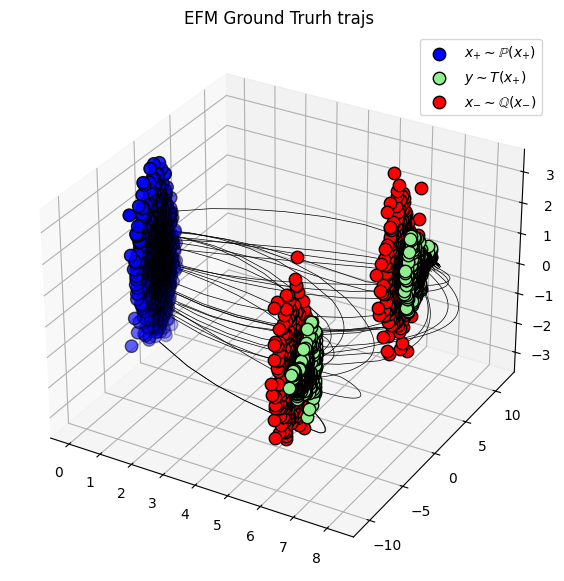

In [26]:
fig = efm.plotTrajectories(traj=traj,
                           p_samples=p_samples,
                           q_samples=q_samples, title="EFM Ground Trurh trajs");

## 2. Gaussian to Swiss Roll

In [27]:
config = Config()

##### common #####
config.device = 'cuda'
config.DIM = 3
config.L = 6.

config.KV = {"z":[-5,5.], "x":[1e-5,8.], "y": [-8,8]}
config.mesh_num_points = 7
##### common #####

##### p_data #####
config.p = Config()
config.p.dim = config.DIM -1
config.p.mean = (0.,0.)
config.p.x_loc = 0.
config.p.std = 1.
config.p.cov = None
##### p_data #####

##### q_data #####
config.q =  Config()
config.q.dim = config.DIM -1
config.q.x_loc = 6.
config.q.swiss_noise = None
##### q_data #####

##### EFM #####
config.training = Config()

config.training = Config()
config.training.stability = True
config.training.gamma = 1e-7
config.training.epsilon=0.3
config.training.interpolation='mesh'
config.training.M = 20.
config.training.tau = .08
config.training.sigma_end = .8
config.training.batch_size =2048
config.training.small_batch_size =1024
config.training.restrict_M = False
config.training.training_steps = 8000
##### EFM #####



config.model = Config()
config.model.embed_dim = 128
config.model.hidden_layers_x = [config.DIM-1, 1024*(config.DIM-1),
                                1024*(config.DIM-1),config.model.embed_dim]
config.model.hidden_layers = [ config.model.embed_dim, 1024*(config.DIM),
                              1024*(config.DIM), config.DIM]
config.model.lr =1e-4

##### ode #####
config.ode = Config()
config.ode.step = .5
config.ode.gamma = 0.
config.ode.behind_step = 1.5
config.ode.behind_num_steps = 350
##### ode #####

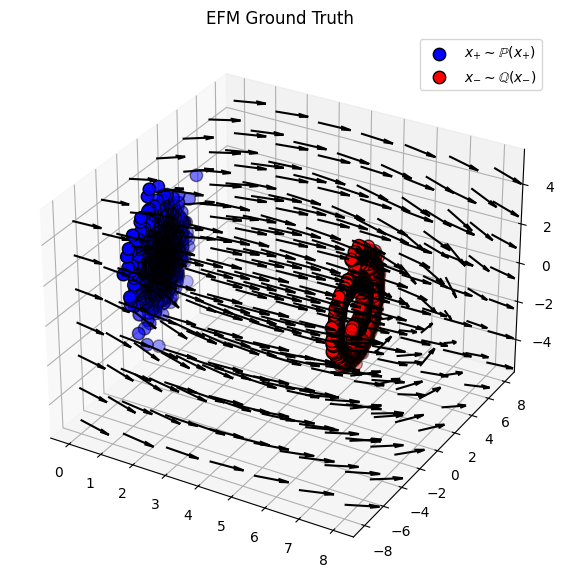

In [28]:
p_dist = MultiDimStackedGauss(config)
q_dist = SwissRollSampler(config)

p_samples = p_dist.sample(config.training.batch_size).to(config.device)
q_samples = q_dist.sample(config.training.batch_size).to(config.device)
efm = EFM(config)

mesh = efm.get_mesh(kv=config.KV,
                    mesh_num_points=config.mesh_num_points).to(config.device)
field = efm.GroundTruth(perturbed_samples_vec=mesh.clone(),
                        p_samples=p_samples, q_samples=q_samples)

fig = efm.plotVectorField(mesh=mesh, field=field,
                          p_samples=p_samples,
                          q_samples=q_samples)

In [29]:
config.ode.step = .5
config.ode.gamma = 0.
config.ode.behind_step = .025
config.ode.behind_num_steps = 650

In [30]:
ode = DippoleGroundTrurthEFMODESolver(config)
init = p_dist.sample(config.training.small_batch_size).to(config.device)
init[:,0] = config.training.epsilon
maps, traj = ode(efm, init , p_samples.clone(), q_samples.clone())
traj = torch.stack(traj,dim=0)

100%|██████████| 650/650 [00:02<00:00, 317.05it/s]


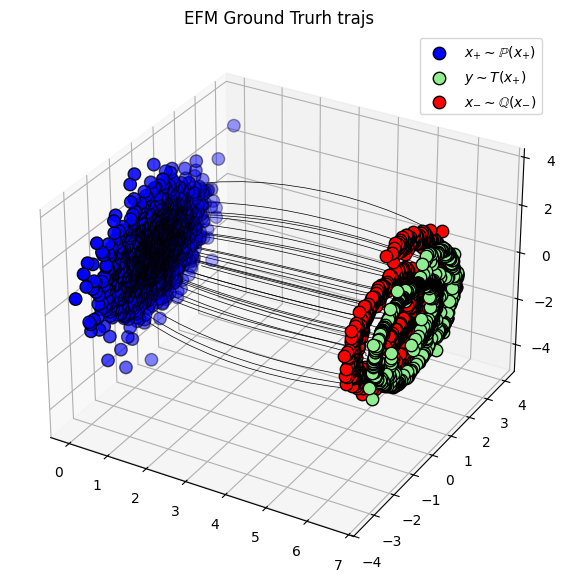

In [31]:
fig = efm.plotTrajectories(traj=traj,
                           p_samples=p_samples,
                           q_samples=q_samples, title="EFM Ground Trurh trajs");

In [ ]:
# ── 2D comparison: T(P) vs Q at z = L (Poisson, Swiss Roll) ─────────────────
fig_cmp = efm.plotComparison2D(traj=traj, q_samples=q_samples,
                                title="Poisson – T(P) vs Swiss Roll  [2D]")
plt.show()

## 3. Yukawa / Screened-Poisson Field for various *m*

The **Yukawa (screened-Poisson) potential** generalises the Coulomb field by introducing an
exponential screening length $1/m$.  Its augmented-space Green's function is (eq. 52 in the paper):

$$G(\mathbf{x},t;\mathbf{x}') = \frac{1}{(2\pi)^{(N+1)/2}}
\left(\frac{m}{\rho}\right)^{\!\!(N-1)/2} K_{\frac{N-1}{2}}(m\rho),
\qquad \rho = \sqrt{t^2+r^2}$$

Taking $-\nabla G$ yields the scalar kernel weight used below:

$$w_\text{Yukawa}(\rho) = \frac{K_{\nu}(m\rho)}{\rho^{\nu}},
\quad \nu = \tfrac{N+1}{2} = \tfrac{\text{DIM}}{2}$$

* $m = 0$ recovers the standard Poisson / Coulomb field (Section 1).  
* Larger $m$ → stronger screening → only nearby charges contribute to the field.

In [33]:
# ── Config: reuse Gaussian → Mixture of Gaussians setup ─────────────────────
config3 = Config()

config3.device = 'cuda'
config3.DIM = 3
config3.L = 6.

config3.KV = {"z": [-5, 5.], "x": [1e-5, 8.], "y": [-8, 8]}
config3.mesh_num_points = 7

config3.p = Config()
config3.p.dim = config3.DIM - 1
config3.p.mean = (0., 0.)
config3.p.x_loc = 0.
config3.p.std = 1.
config3.p.cov = None

config3.q = Config()
config3.q.dim = config3.DIM - 1
config3.q.num_components = 2
config3.q.mix_probs = (0.5, 0.5)
config3.q.means = ((-8., 0.), (8., 0.))
config3.q.stds = (1., 1.)
config3.q.cov = None
config3.q.x_loc = config3.L

config3.training = Config()
config3.training.stability = True
config3.training.gamma = 1e-7
config3.training.epsilon = 0.3
config3.training.interpolation = 'mesh'
config3.training.M = 20.
config3.training.tau = .08
config3.training.sigma_end = .8
config3.training.batch_size = 2048
config3.training.small_batch_size = 1024
config3.training.restrict_M = False

config3.ode = Config()
config3.ode.step = 1.
config3.ode.gamma = 0.
config3.ode.behind_step = 1.5
config3.ode.behind_num_steps = 350

# Fixed samples and mesh for fair comparison across m values
p_dist3 = MultiDimStackedGauss(config3)
q_dist3 = MultiDimStackedMixtureGauss(config3)

torch.manual_seed(42)
p_samples3 = p_dist3.sample(config3.training.batch_size).to(config3.device)
q_samples3 = q_dist3.sample(config3.training.batch_size).to(config3.device)

efm3 = EFM(config3)
mesh3 = efm3.get_mesh(kv=config3.KV, mesh_num_points=config3.mesh_num_points).to(config3.device)

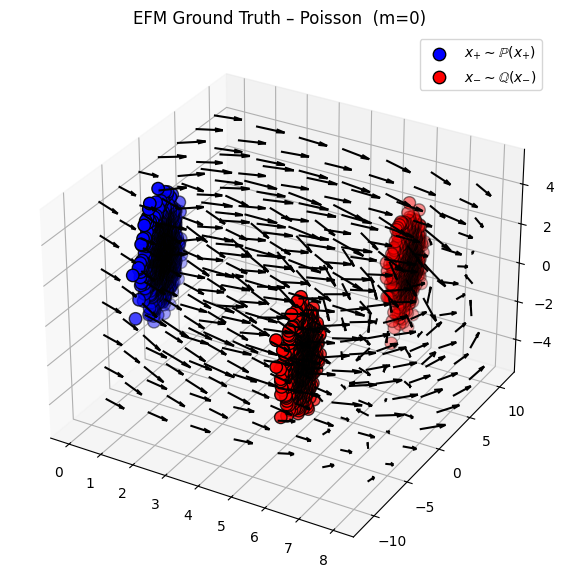

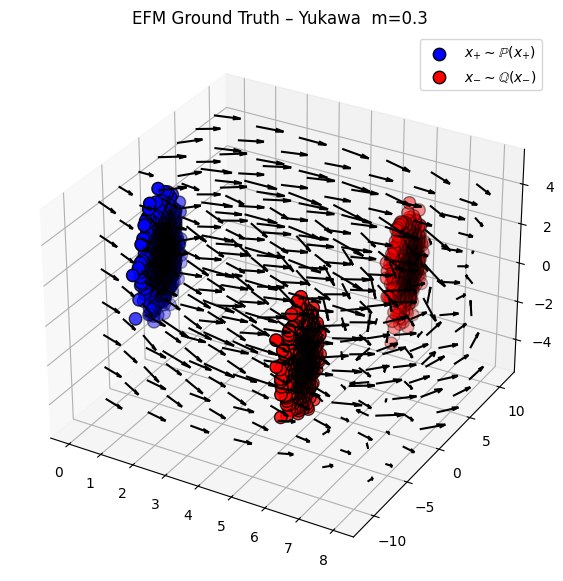

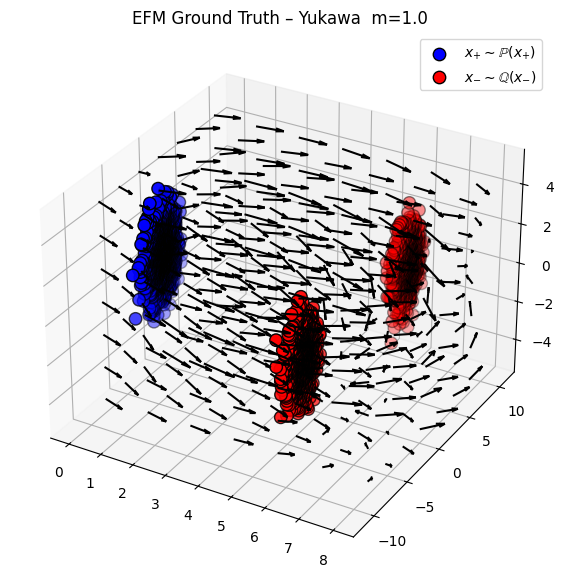

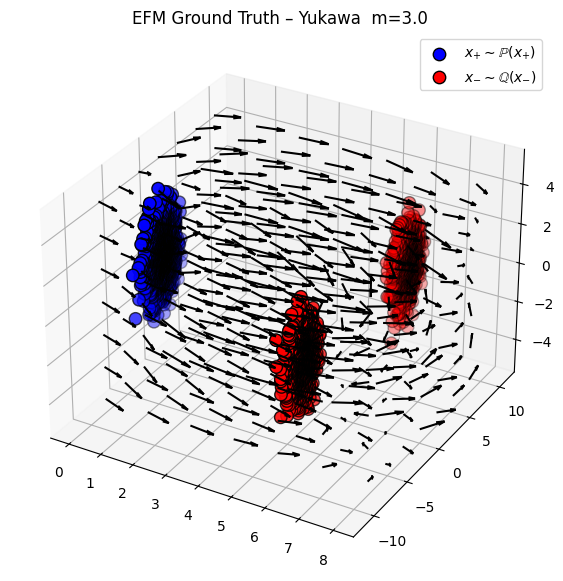

In [34]:
# ── Vector fields for m = 0 (Poisson), 0.3, 1.0, 3.0 ────────────────────────
m_values = [0.0, 0.3, 1.0, 3.0]

for m in m_values:
    if m == 0.0:
        field3 = efm3.GroundTruth(perturbed_samples_vec=mesh3.clone(),
                                   p_samples=p_samples3, q_samples=q_samples3)
    else:
        field3 = efm3.GroundTruthYukawa(mesh3.clone(), p_samples3, q_samples3, m=m)

    label = "Poisson  (m=0)" if m == 0.0 else f"Yukawa  m={m}"
    fig = efm3.plotVectorField(mesh=mesh3, field=field3,
                               p_samples=p_samples3, q_samples=q_samples3,
                               title=f"EFM Ground Truth – {label}")
    plt.show()

100%|██████████| 350/350 [00:00<00:00, 568.63it/s]


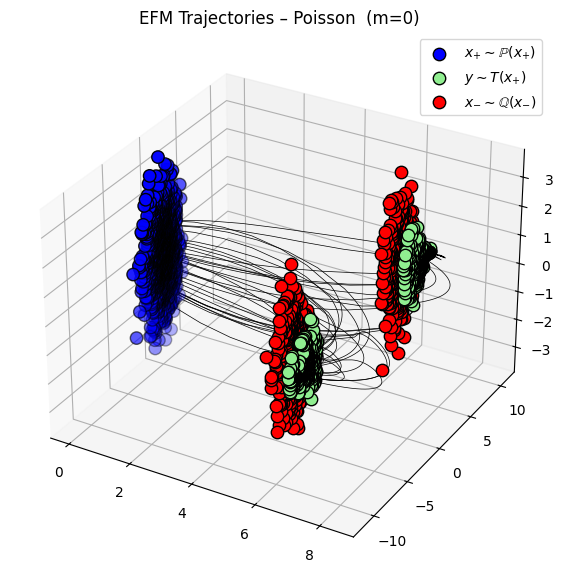

100%|██████████| 350/350 [00:34<00:00, 10.28it/s]


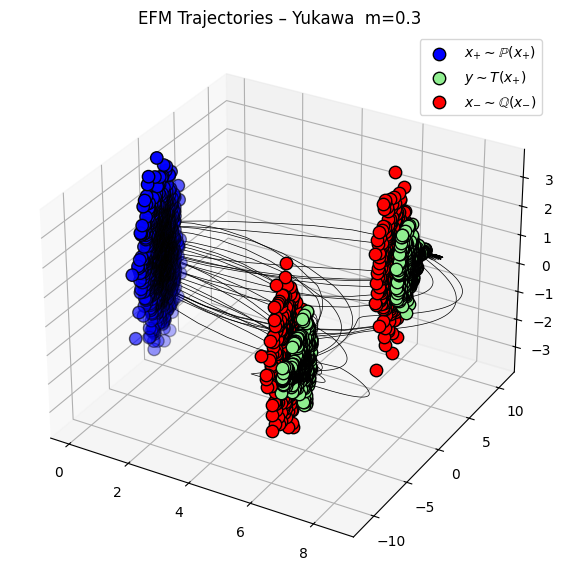

100%|██████████| 350/350 [00:19<00:00, 17.58it/s] 


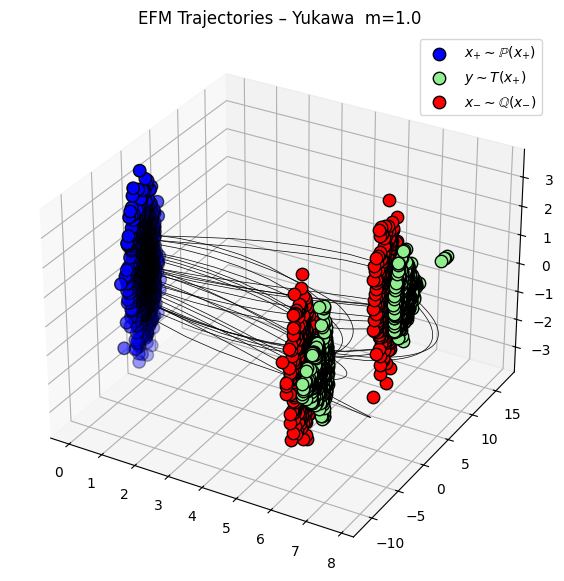

100%|██████████| 350/350 [00:24<00:00, 14.02it/s] 


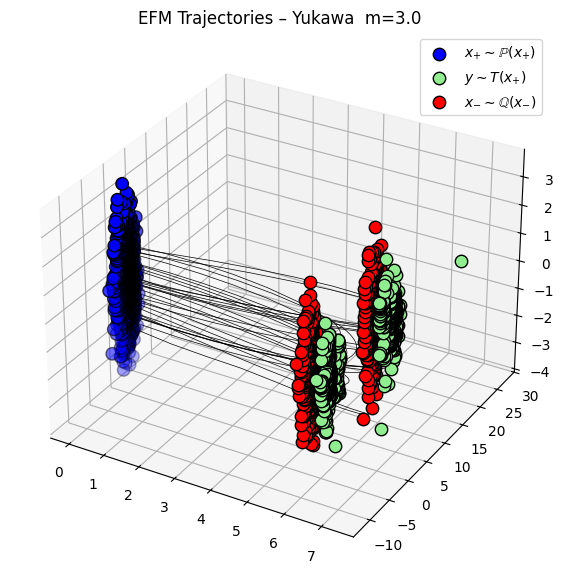

In [35]:
# ── Trajectories for each m value ────────────────────────────────────────────
for m in m_values:
    torch.manual_seed(42)
    init3 = p_dist3.sample(config3.training.small_batch_size).to(config3.device)
    init3[:, 0] = config3.training.epsilon

    ode3 = DippoleGroundTrurthEFMODESolver(config3, m=m)
    maps3, traj3 = ode3(efm3, init3, p_samples3.clone(), q_samples3.clone())
    traj3_t = torch.stack(traj3, dim=0)

    label = "Poisson  (m=0)" if m == 0.0 else f"Yukawa  m={m}"
    fig = efm3.plotTrajectories(traj=traj3_t,
                                p_samples=p_samples3, q_samples=q_samples3,
                                title=f"EFM Trajectories – {label}")
    plt.show()

## 4. Yukawa / Screened-Poisson Field for various *m* — Gaussian → Swiss Roll

Same sweep over $m$ as in Section 3, but now the target distribution $Q$ is the **Swiss Roll** manifold (Section 2). This lets us observe how screening affects transport to a highly non-Gaussian, curved target.

In [ ]:
# ── Config: Gaussian → Swiss Roll (mirrors Section 2) ────────────────────────
config4 = Config()

config4.device = 'cuda'
config4.DIM = 3
config4.L = 6.

config4.KV = {"z": [-5, 5.], "x": [1e-5, 8.], "y": [-8, 8]}
config4.mesh_num_points = 7

config4.p = Config()
config4.p.dim = config4.DIM - 1
config4.p.mean = (0., 0.)
config4.p.x_loc = 0.
config4.p.std = 1.
config4.p.cov = None

config4.q = Config()
config4.q.dim = config4.DIM - 1
config4.q.x_loc = config4.L
config4.q.swiss_noise = None

config4.training = Config()
config4.training.stability = True
config4.training.gamma = 1e-7
config4.training.epsilon = 0.3
config4.training.interpolation = 'mesh'
config4.training.M = 20.
config4.training.tau = .08
config4.training.sigma_end = .8
config4.training.batch_size = 2048
config4.training.small_batch_size = 1024
config4.training.restrict_M = False

# ODE params from Section 2 (Swiss Roll needs finer steps)
config4.ode = Config()
config4.ode.step = .5
config4.ode.gamma = 0.
config4.ode.behind_step = .025
config4.ode.behind_num_steps = 650

# Fixed samples and mesh
p_dist4 = MultiDimStackedGauss(config4)
q_dist4 = SwissRollSampler(config4)

torch.manual_seed(42)
p_samples4 = p_dist4.sample(config4.training.batch_size).to(config4.device)
q_samples4 = q_dist4.sample(config4.training.batch_size).to(config4.device)

efm4 = EFM(config4)
mesh4 = efm4.get_mesh(kv=config4.KV, mesh_num_points=config4.mesh_num_points).to(config4.device)

In [ ]:
# ── Vector fields for m = 0 (Poisson), 0.3, 1.0, 3.0 ────────────────────────
m_values = [0.0, 0.3, 1.0, 3.0]

for m in m_values:
    if m == 0.0:
        field4 = efm4.GroundTruth(perturbed_samples_vec=mesh4.clone(),
                                   p_samples=p_samples4, q_samples=q_samples4)
    else:
        field4 = efm4.GroundTruthYukawa(mesh4.clone(), p_samples4, q_samples4, m=m)

    label = "Poisson  (m=0)" if m == 0.0 else f"Yukawa  m={m}"
    fig = efm4.plotVectorField(mesh=mesh4, field=field4,
                               p_samples=p_samples4, q_samples=q_samples4,
                               title=f"EFM Ground Truth [Swiss Roll] – {label}")
    plt.show()

In [ ]:
# ── Trajectories + KL divergence for each m value ────────────────────────────
for m in m_values:
    torch.manual_seed(42)
    init4 = p_dist4.sample(config4.training.small_batch_size).to(config4.device)
    init4[:, 0] = config4.training.epsilon

    ode4 = DippoleGroundTrurthEFMODESolver(config4, m=m)
    maps4, traj4 = ode4(efm4, init4, p_samples4.clone(), q_samples4.clone())
    traj4_t = torch.stack(traj4, dim=0)

    label = "Poisson  (m=0)" if m == 0.0 else f"Yukawa  m={m}"
    fig, kl = efm4.plotTrajectories(traj=traj4_t,
                                    p_samples=p_samples4, q_samples=q_samples4,
                                    title=f"EFM Trajectories [Swiss Roll] – {label}")
    plt.show()

In [ ]:
# ── 2D comparison grid: T(P) vs Q (Swiss Roll) for each m ───────────────────
# Re-runs ODE (fast) and lays out results in a 1×len(m_values) subplot grid.
n_m  = len(m_values)
fig_grid, axes = plt.subplots(1, n_m, figsize=(5 * n_m, 5),
                               sharex=True, sharey=True)

q_xy = q_samples4[:, 1:3].cpu().contiguous().numpy()

for ax, m in zip(axes, m_values):
    torch.manual_seed(42)
    init4 = p_dist4.sample(config4.training.small_batch_size).to(config4.device)
    init4[:, 0] = config4.training.epsilon

    ode4 = DippoleGroundTrurthEFMODESolver(config4, m=m)
    _, traj4 = ode4(efm4, init4, p_samples4.clone(), q_samples4.clone())
    traj4_t = torch.stack(traj4, dim=0)

    transported = traj4_t[-1][:, 1:3].cpu().contiguous().numpy()

    # KL divergence
    from src.efm_field import _kl_knn_estimate
    kl = _kl_knn_estimate(transported, q_xy)

    ax.scatter(q_xy[:, 0], q_xy[:, 1],
               c='red', alpha=0.3, s=8, label=r'$Q$ (Swiss Roll)')
    ax.scatter(transported[:, 0], transported[:, 1],
               c='limegreen', edgecolors='black', linewidths=0.3,
               alpha=0.8, s=12, label=r'$T(P)$')

    label = "Poisson  (m=0)" if m == 0.0 else f"Yukawa  m={m}"
    ax.set_title(f"{label}\n$D_{{KL}} = {kl:.4f}$")
    ax.set_xlabel(r'$x_1$')
    if ax is axes[0]:
        ax.set_ylabel(r'$x_2$')
        ax.legend(loc='upper right', fontsize=8)

fig_grid.suptitle("2D comparison: T(P) vs Q (Swiss Roll)  —  varying Yukawa mass $m$",
                  fontsize=13)
fig_grid.tight_layout()
plt.show()